In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("marketing_AB (Task11).csv")

In [2]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
df.info()
df['test group'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


test group
ad     564577
psa     23524
Name: count, dtype: int64

In [4]:
df.shape

(588101, 7)

In [27]:
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [28]:
df['test group'].unique()


array(['ad', 'psa'], dtype=object)

In [35]:
## Split Control & Treatment Groups

control= df[df['test group'] == 'psa']          #psa = control group (no ads)
treatment= df[df['test group'] == 'ad']         #ad = treatment group (ads shown)

# Why? - A/B testing always compares two independent groups

 ## Hypotheses (CORE CONCEPT)
   1. Null Hypothesis (H₀):
                 - There is no difference in conversion rate between control and treatment.

   2. Alternative Hypothesis (H₁):
                -  There is a significant difference in conversion rate.

In [31]:
df['converted'] = df['converted'].astype(int)


In [32]:
df.head()


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,0,130,Monday,20
1,1,1119715,ad,0,93,Tuesday,22
2,2,1144181,ad,0,21,Tuesday,18
3,3,1435133,ad,0,355,Tuesday,10
4,4,1015700,ad,0,276,Friday,14


In [34]:
# Remove rows with missing values
df = df.dropna(subset=['converted', 'test group'])


In [36]:
# Check size:
control.shape, treatment.shape


((23524, 7), (564577, 7))

In [41]:
control_rate= control['converted'].mean()
treatment_rate= treatment['converted'].mean()

# round(control_rate,3), round(treatment_rate,3)         # to see values as decimal values
round(control_rate*100,3), round(treatment_rate*100,3)   # to see values as % value


## Mean of converted = conversion rate
   # - This gives business insight immediately

(np.float64(1.785), np.float64(2.555))

# here, meanes of rate is:
            - 1.8% users converted without ads
            - 2.6% users converted after seeing ads
            -> means Users who were shown advertisements had a higher conversion rate compared to users who were not shown ads.

In [42]:
# Conversion Lift
lift = treatment_rate - control_rate
round(lift * 100, 2)                              # Ads increased conversion by ~0.77 percentage points

np.float64(0.77)

In [56]:
t_stat, p_value = ttest_ind(
    control['converted'],
    treatment['converted'],
    equal_var=False
)

# round(t_stat,2), format(p_value,'.5e')

print(f"t_statistics: {t_stat:.2f}")
print(f"p_value: {p_value:.5e}")


t_statistics: -8.66
p_value: 5.10761e-18


# meaning of t_stat & p_value

  t_statistics means: Measures how far apart the two group means are
                      Large absolute value → strong difference
                      
      1. ### Rule of thumb: (for t_stat)
            |t| > 2 → meaningful difference
            here, is 8.66 → VERY STRONG
            Sign does NOT affect decision, magnitude matters
            here, -ve sign means: treatment conversion > control

  p_value means: p < 0.05 → Treatment works    (reject null hypothisis)...there is "Statistically significant difference"
                 p ≥ 0.05 → Difference due to chance

      2. #### rule for p-value decision:
                    if p_value < alpha:
                         decision = "Reject Null Hypothesis (Significant Difference)"
                    else:
                         decision = "Fail to Reject Null Hypothesis (No Significant Difference)"
 
      p_value common threshold is : alpha = 0.05
           here, p_value= 5.107*10^-18= 0.000000000000000005 = too small than alpha
           “With a very low p-value, we can confidently conclude that the higher conversion rate in the treatment group is not due to random chance,              indicating that advertisements have a positive impact on user conversion.”

     
# conclusion of t_test:
“An independent two-sample t-test was performed to compare conversion rates between control and treatment groups. The test resulted in a     statistically significant difference (p < 0.05), confirming that the treatment group achieved higher conversions.”

# Why t_test?
           - Comparing two groups
           - Binary outcome (0/1)
           - Very common in A/B testing

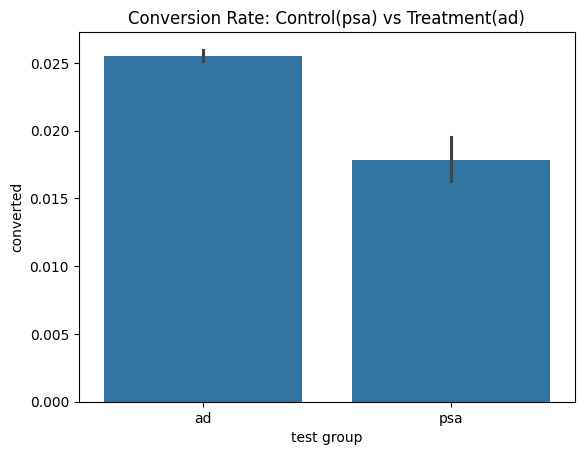

In [57]:
# Visualize Conversion Rates

sns.barplot(x= 'test group', y= 'converted', data=df)
plt.title("Conversion Rate: Control(psa) vs Treatment(ad)")
y_label= ("Conversion Rate")
x_label= ("test group")
plt.show()

In [61]:
# Summary Table
summary= pd.DataFrame({
          'test group': ['Control', 'Treatment'],
          'Conversion Rate': ['control_rate', 'treatment_rate']
})

summary.to_csv("ab_test_summary.csv", index=False)